In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 1. Load Preprocessed Datasets

Specify the paths to your preprocessed train/val/test files.

In [2]:
# Update these paths to match your preprocessed files
preprocessed_dir = Path("data/preprocessed")

# Example: Change "breast_cancer" to match your target domain
target_domain_name = "breast_cancer"  # Update this!

train_path = preprocessed_dir / f"{target_domain_name}_train.npz"
val_path = preprocessed_dir / f"{target_domain_name}_val.npz"
test_path = preprocessed_dir / f"{target_domain_name}_test.npz"

print(f"📁 Checking preprocessed files for target domain: {target_domain_name}")
print(f"  Train: {'✅ Found' if train_path.exists() else '❌ Not found'} - {train_path}")
print(f"  Val:   {'✅ Found' if val_path.exists() else '❌ Not found'} - {val_path}")
print(f"  Test:  {'✅ Found' if test_path.exists() else '❌ Not found'} - {test_path}")

📁 Checking preprocessed files for target domain: breast_cancer
  Train: ✅ Found - data\preprocessed\breast_cancer_train.npz
  Val:   ✅ Found - data\preprocessed\breast_cancer_val.npz
  Test:  ✅ Found - data\preprocessed\breast_cancer_test.npz


## 2. Verify File Structure

Check that all required keys are present: `images`, `labels1`, `labels2`

In [3]:
def verify_npz_structure(npz_path: Path, split_name: str):
    """Verify that an .npz file has the correct structure for TwoLabelDataset."""
    print(f"\n{'='*60}")
    print(f"Verifying {split_name} dataset: {npz_path.name}")
    print('='*60)
    
    if not npz_path.exists():
        print(f"❌ ERROR: File not found!")
        return None
    
    # Load data
    data = np.load(npz_path, allow_pickle=True)
    
    # Check required keys
    required_keys = ['images', 'labels1', 'labels2']
    print(f"\n🔑 Checking required keys:")
    all_keys_present = True
    for key in required_keys:
        if key in data.files:
            print(f"  ✅ {key}")
        else:
            print(f"  ❌ {key} - MISSING!")
            all_keys_present = False
    
    if not all_keys_present:
        print(f"\n❌ ERROR: Missing required keys!")
        return None
    
    # Extract arrays
    images = data['images']
    labels1 = data['labels1']
    labels2 = data['labels2']
    
    # Verify shapes
    print(f"\n📊 Dataset shapes:")
    print(f"  images:  {images.shape} ({images.dtype})")
    print(f"  labels1: {labels1.shape} ({labels1.dtype})")
    print(f"  labels2: {labels2.shape} ({labels2.dtype})")
    
    # Check consistency
    n_samples = len(images)
    if len(labels1) == n_samples and len(labels2) == n_samples:
        print(f"  ✅ All arrays have consistent length: {n_samples} samples")
    else:
        print(f"  ❌ ERROR: Inconsistent array lengths!")
        return None
    
    # Check label distributions
    print(f"\n📈 Label distributions:")
    labels1_dist = Counter(labels1)
    labels2_dist = Counter(labels2)
    
    print(f"  labels1 (cancer_binary): {dict(labels1_dist)}")
    print(f"  labels2 (target_domain): {dict(labels2_dist)}")
    
    # Calculate percentages
    labels1_pct = {k: f"{v/n_samples*100:.1f}%" for k, v in labels1_dist.items()}
    labels2_pct = {k: f"{v/n_samples*100:.1f}%" for k, v in labels2_dist.items()}
    
    print(f"\n  labels1 percentages: {labels1_pct}")
    print(f"  labels2 percentages: {labels2_pct}")
    
    print(f"\n✅ {split_name} dataset structure is VALID")
    
    return {
        'images': images,
        'labels1': labels1,
        'labels2': labels2,
        'n_samples': n_samples,
        'labels1_dist': labels1_dist,
        'labels2_dist': labels2_dist
    }

# Verify all splits
train_data = verify_npz_structure(train_path, "TRAIN")
val_data = verify_npz_structure(val_path, "VALIDATION")
test_data = verify_npz_structure(test_path, "TEST")


Verifying TRAIN dataset: breast_cancer_train.npz

🔑 Checking required keys:
  ✅ images
  ✅ labels1
  ✅ labels2

📊 Dataset shapes:
  images:  (28000, 224, 224, 3) (uint8)
  labels1: (28000,) (int64)
  labels2: (28000,) (int64)
  ✅ All arrays have consistent length: 28000 samples

📈 Label distributions:
  labels1 (cancer_binary): {1: 14000, 0: 14000}
  labels2 (target_domain): {0: 21000, 1: 7000}

  labels1 percentages: {1: '50.0%', 0: '50.0%'}
  labels2 percentages: {0: '75.0%', 1: '25.0%'}

✅ TRAIN dataset structure is VALID

Verifying VALIDATION dataset: breast_cancer_val.npz

🔑 Checking required keys:
  ✅ images
  ✅ labels1
  ✅ labels2

📊 Dataset shapes:
  images:  (6000, 224, 224, 3) (uint8)
  labels1: (6000,) (int64)
  labels2: (6000,) (int64)
  ✅ All arrays have consistent length: 6000 samples

📈 Label distributions:
  labels1 (cancer_binary): {1: 3000, 0: 3000}
  labels2 (target_domain): {0: 4471, 1: 1529}

  labels1 percentages: {1: '50.0%', 0: '50.0%'}
  labels2 percentages: {

## 3. Verify Target Domain Labeling

Check that labels2 correctly identifies the target domain samples.

**Expected behavior:**
- labels2 = 1 for samples from the target domain
- labels2 = 0 for samples from other domains

In [4]:
print("="*60)
print("TARGET DOMAIN LABELING VERIFICATION")
print("="*60)

if train_data is not None:
    labels2_dist = train_data['labels2_dist']
    n_samples = train_data['n_samples']
    
    n_target = labels2_dist.get(1, 0)
    n_other = labels2_dist.get(0, 0)
    
    print(f"\n📊 Training set labels2 distribution:")
    print(f"  Target domain (labels2=1): {n_target} samples ({n_target/n_samples*100:.1f}%)")
    print(f"  Other domains (labels2=0):  {n_other} samples ({n_other/n_samples*100:.1f}%)")
    
    if n_target > 0 and n_other > 0:
        print(f"\n✅ PASS: Both target and other domain samples are present")
    elif n_target == 0:
        print(f"\n⚠️  WARNING: No target domain samples found (all labels2=0)")
    elif n_other == 0:
        print(f"\n⚠️  WARNING: No other domain samples found (all labels2=1)")
    
    # Check if labeling makes sense (typically not 100% one class)
    if n_target == n_samples or n_other == n_samples:
        print(f"\n⚠️  WARNING: All samples have the same labels2 value")
        print(f"    This might indicate incorrect target_domain selection")
else:
    print("\n❌ Cannot verify - train dataset not loaded")

TARGET DOMAIN LABELING VERIFICATION

📊 Training set labels2 distribution:
  Target domain (labels2=1): 7000 samples (25.0%)
  Other domains (labels2=0):  21000 samples (75.0%)

✅ PASS: Both target and other domain samples are present


## 4. Verify Data Types

Check that data types are compatible with PyTorch and the experiment framework.

In [5]:
print("="*60)
print("DATA TYPE VERIFICATION")
print("="*60)

def check_data_types(data_dict, split_name):
    if data_dict is None:
        return
    
    print(f"\n{split_name}:")
    images = data_dict['images']
    labels1 = data_dict['labels1']
    labels2 = data_dict['labels2']
    
    # Check image dtype
    if images.dtype == np.uint8:
        print(f"  ✅ images: {images.dtype} (will be converted to float32 by transforms)")
    elif images.dtype in [np.float32, np.float64]:
        print(f"  ✅ images: {images.dtype}")
    else:
        print(f"  ⚠️  images: {images.dtype} (unexpected dtype)")
    
    # Check label dtypes
    if labels1.dtype in [np.int64, np.int32]:
        print(f"  ✅ labels1: {labels1.dtype}")
    else:
        print(f"  ⚠️  labels1: {labels1.dtype} (should be int64 or int32)")
    
    if labels2.dtype in [np.int64, np.int32]:
        print(f"  ✅ labels2: {labels2.dtype}")
    else:
        print(f"  ⚠️  labels2: {labels2.dtype} (should be int64 or int32)")
    
    # Check image value range
    img_min, img_max = images.min(), images.max()
    print(f"\n  Image value range: [{img_min}, {img_max}]")
    
    if images.dtype == np.uint8:
        if img_min >= 0 and img_max <= 255:
            print(f"  ✅ Values in expected uint8 range [0, 255]")
        else:
            print(f"  ⚠️  Values outside expected uint8 range")
    elif images.dtype in [np.float32, np.float64]:
        if -1.5 <= img_min <= 1.5 and -1.5 <= img_max <= 1.5:
            print(f"  ✅ Values in expected normalized range (approx [-1, 1])")
        elif 0 <= img_min <= 1 and 0 <= img_max <= 1:
            print(f"  ✅ Values in normalized range [0, 1]")
        else:
            print(f"  ⚠️  Unexpected value range for float images")

check_data_types(train_data, "TRAIN")
check_data_types(val_data, "VALIDATION")
check_data_types(test_data, "TEST")

DATA TYPE VERIFICATION

TRAIN:
  ✅ images: uint8 (will be converted to float32 by transforms)
  ✅ labels1: int64
  ✅ labels2: int64

  Image value range: [0, 255]
  ✅ Values in expected uint8 range [0, 255]

VALIDATION:
  ✅ images: uint8 (will be converted to float32 by transforms)
  ✅ labels1: int64
  ✅ labels2: int64

  Image value range: [0, 255]
  ✅ Values in expected uint8 range [0, 255]

TEST:
  ✅ images: uint8 (will be converted to float32 by transforms)
  ✅ labels1: int64
  ✅ labels2: int64

  Image value range: [0, 255]
  ✅ Values in expected uint8 range [0, 255]


## 5. Test Loading with TwoLabelDataset

Simulate loading the dataset using the experiment framework's TwoLabelDataset class structure.

In [6]:
import torch
from torch.utils.data import Dataset

class TwoLabelDatasetTest(Dataset):
    """Test dataset class matching the experiment framework structure."""
    
    def __init__(self, file_path: str):
        data = np.load(file_path, allow_pickle=True)
        self.images = data['images']
        self.labels1 = data['labels1']
        self.labels2 = data['labels2']
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx: int) -> dict:
        return {
            "pixel_values": self.images[idx],
            "labels1": int(self.labels1[idx]),
            "labels2": int(self.labels2[idx]),
        }

print("="*60)
print("TESTING DATASET LOADING")
print("="*60)

try:
    # Test loading train dataset
    if train_path.exists():
        print(f"\n📦 Loading training dataset...")
        train_dataset = TwoLabelDatasetTest(str(train_path))
        print(f"  ✅ Loaded successfully: {len(train_dataset)} samples")
        
        # Test getting a sample
        sample = train_dataset[0]
        print(f"\n📊 Sample structure:")
        print(f"  Keys: {list(sample.keys())}")
        print(f"  pixel_values shape: {sample['pixel_values'].shape}")
        print(f"  labels1: {sample['labels1']} (type: {type(sample['labels1']).__name__})")
        print(f"  labels2: {sample['labels2']} (type: {type(sample['labels2']).__name__})")
        
        print(f"\n✅ Dataset structure matches TwoLabelDataset requirements!")
    else:
        print(f"\n⚠️  Train file not found, skipping test")
        
except Exception as e:
    print(f"\n❌ ERROR loading dataset: {e}")
    import traceback
    traceback.print_exc()

TESTING DATASET LOADING

📦 Loading training dataset...
  ✅ Loaded successfully: 28000 samples

📊 Sample structure:
  Keys: ['pixel_values', 'labels1', 'labels2']
  pixel_values shape: (224, 224, 3)
  labels1: 1 (type: int)
  labels2: 0 (type: int)

✅ Dataset structure matches TwoLabelDataset requirements!


## 6. Visualize Label Distributions

Compare label distributions across train/val/test splits.

✅ Visualization saved as 'preprocessed_dataset_verification.png'


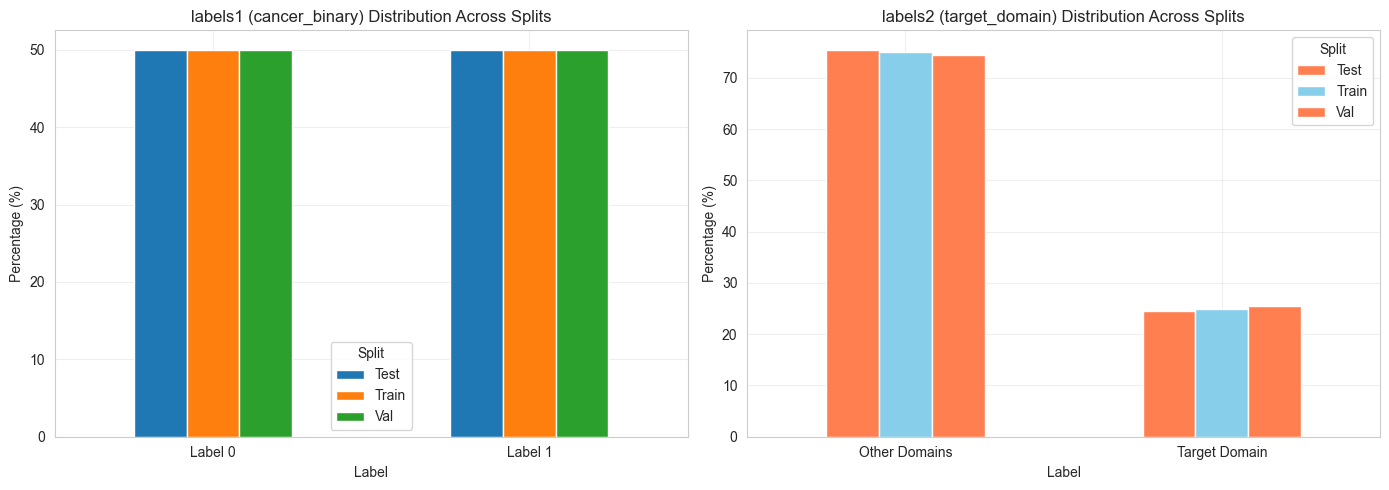

In [7]:
# Collect data for visualization
if all([train_data, val_data, test_data]):
    splits = ['Train', 'Val', 'Test']
    datasets = [train_data, val_data, test_data]
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot labels1 distribution
    labels1_data = []
    for split, data in zip(splits, datasets):
        dist = data['labels1_dist']
        for label, count in dist.items():
            labels1_data.append({
                'Split': split,
                'Label': f'Label {label}',
                'Count': count,
                'Percentage': count / data['n_samples'] * 100
            })
    
    df_labels1 = pd.DataFrame(labels1_data)
    pivot1 = df_labels1.pivot(index='Label', columns='Split', values='Percentage')
    pivot1.plot(kind='bar', ax=axes[0], rot=0)
    axes[0].set_title('labels1 (cancer_binary) Distribution Across Splits')
    axes[0].set_ylabel('Percentage (%)')
    axes[0].legend(title='Split')
    axes[0].grid(True, alpha=0.3)
    
    # Plot labels2 distribution
    labels2_data = []
    for split, data in zip(splits, datasets):
        dist = data['labels2_dist']
        for label, count in dist.items():
            label_name = 'Target Domain' if label == 1 else 'Other Domains'
            labels2_data.append({
                'Split': split,
                'Label': label_name,
                'Count': count,
                'Percentage': count / data['n_samples'] * 100
            })
    
    df_labels2 = pd.DataFrame(labels2_data)
    pivot2 = df_labels2.pivot(index='Label', columns='Split', values='Percentage')
    pivot2.plot(kind='bar', ax=axes[1], rot=0, color=['coral', 'skyblue'])
    axes[1].set_title('labels2 (target_domain) Distribution Across Splits')
    axes[1].set_ylabel('Percentage (%)')
    axes[1].legend(title='Split')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('preprocessed_dataset_verification.png', dpi=150, bbox_inches='tight')
    print("✅ Visualization saved as 'preprocessed_dataset_verification.png'")
    plt.show()
else:
    print("⚠️  Not all datasets loaded, skipping visualization")

## 7. Summary Report

Generate a final summary of the verification results.

In [8]:
print("="*80)
print(" " * 25 + "VERIFICATION SUMMARY")
print("="*80)

if all([train_data, val_data, test_data]):
    total_samples = train_data['n_samples'] + val_data['n_samples'] + test_data['n_samples']
    
    print(f"\n✅ All datasets loaded successfully!")
    print(f"\n📊 Dataset Sizes:")
    print(f"  Training:   {train_data['n_samples']:>6} samples ({train_data['n_samples']/total_samples*100:>5.1f}%)")
    print(f"  Validation: {val_data['n_samples']:>6} samples ({val_data['n_samples']/total_samples*100:>5.1f}%)")
    print(f"  Test:       {test_data['n_samples']:>6} samples ({test_data['n_samples']/total_samples*100:>5.1f}%)")
    print(f"  Total:      {total_samples:>6} samples")
    
    print(f"\n✅ Structure Validation:")
    print(f"  ✓ All required keys present (images, labels1, labels2)")
    print(f"  ✓ Array shapes are consistent")
    print(f"  ✓ Data types are compatible")
    print(f"  ✓ Dataset matches TwoLabelDataset format")
    
    print(f"\n✅ Label Validation:")
    print(f"  ✓ labels1 (cancer_binary) contains: {sorted(set(train_data['labels1']))}")
    print(f"  ✓ labels2 (target_domain) contains: {sorted(set(train_data['labels2']))}")
    
    # Check for potential issues
    print(f"\n🔍 Quality Checks:")
    
    # Check class balance
    train_l1_dist = train_data['labels1_dist']
    train_l2_dist = train_data['labels2_dist']
    
    # Check labels1 balance
    if len(train_l1_dist) > 1:
        l1_counts = list(train_l1_dist.values())
        l1_ratio = max(l1_counts) / min(l1_counts)
        if l1_ratio < 2:
            print(f"  ✓ labels1 is well balanced (ratio: {l1_ratio:.2f}:1)")
        else:
            print(f"  ⚠️  labels1 is imbalanced (ratio: {l1_ratio:.2f}:1)")
    
    # Check labels2 balance
    if len(train_l2_dist) > 1:
        l2_counts = list(train_l2_dist.values())
        l2_ratio = max(l2_counts) / min(l2_counts)
        if l2_ratio < 2:
            print(f"  ✓ labels2 is well balanced (ratio: {l2_ratio:.2f}:1)")
        else:
            print(f"  ⚠️  labels2 is imbalanced (ratio: {l2_ratio:.2f}:1)")
            print(f"    Note: This is expected if target domain is minority")
    
    print(f"\n" + "="*80)
    print(" " * 20 + "✅ VERIFICATION COMPLETE - DATASETS ARE READY!")
    print("="*80)
    print(f"\nYou can now use these datasets in your experiment configs:")
    print(f"  fold_file_paths:")
    print(f"    - {train_path.absolute()}")
    print(f"    - {val_path.absolute()}")
    print(f"    - {test_path.absolute()}")
    
else:
    print(f"\n❌ VERIFICATION FAILED")
    print(f"\nSome datasets could not be loaded. Please check:")
    print(f"  1. File paths are correct")
    print(f"  2. Files were generated by preprocess_menu.py")
    print(f"  3. Files contain all required keys (images, labels1, labels2)")

                         VERIFICATION SUMMARY

✅ All datasets loaded successfully!

📊 Dataset Sizes:
  Training:    28000 samples ( 70.0%)
  Validation:   6000 samples ( 15.0%)
  Test:         6000 samples ( 15.0%)
  Total:       40000 samples

✅ Structure Validation:
  ✓ All required keys present (images, labels1, labels2)
  ✓ Array shapes are consistent
  ✓ Data types are compatible
  ✓ Dataset matches TwoLabelDataset format

✅ Label Validation:
  ✓ labels1 (cancer_binary) contains: [0, 1]
  ✓ labels2 (target_domain) contains: [0, 1]

🔍 Quality Checks:
  ✓ labels1 is well balanced (ratio: 1.00:1)
  ⚠️  labels2 is imbalanced (ratio: 3.00:1)
    Note: This is expected if target domain is minority

                    ✅ VERIFICATION COMPLETE - DATASETS ARE READY!

You can now use these datasets in your experiment configs:
  fold_file_paths:
    - c:\Users\samue\Capstone_Project\domain-adaptation-multi-cancer\domain-adaptation-multi-cancer-main\data\preprocessed\breast_cancer_train.npz
 